# DS4200 Homework 5

Due: Friday Dec 5th @ 11:59 PM EST

### Submission Instructions
Submit this `ipynb` file included with the coding results to Gradescope (this can also be done via the assignment on Canvas).  To ensure that your submitted files represent your latest code, make sure to give a fresh `Kernel > Restart & Run All` just before uploading the files to gradescope.

### Tips for success
- Start early
- Make use of Piazza
- Make use of Office hour
- Remember to use cells and headings to make the notebook easy to read (if a grader cannot find the answer to a problem, you will receive no points for it)
- Under no circumstances may one student view or share their ungraded homework or quiz with another student [(see also)](http://www.northeastern.edu/osccr/academic-integrity), though you are welcome to **talk about** (not show each other) the problems.

### Part 1 Analysis the Wolfe Primates

These data represent 3 months of interactions among a troop of monkeys, observed in the wild by Linda Wolfe as they sported by a river in Ocala, Florida. Joint presence at the river was coded as an interaction and these were summed within all pairs. 

There are two files for the data. `labels.csv` is the file contains information for each monkey, with their genders, ages and their rank in the troop. `link_m.csv` is the file contains the number of their interaction in the adjacency matrix format. 

Note: when load the `link_m.csv`, set the header to be none.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


In [2]:
# load data
labels = pd.read_csv("labels.csv")
link_m = pd.read_csv("link_m.csv", header=None)

# sort by rank and get ordered ids (adjusted for 0-based index)
ordered_ids = labels.sort_values("Rank")["Id"].to_numpy()
ordered_idx = ordered_ids - 1

# reorder matrix and labels
link_m = link_m.iloc[ordered_idx, ordered_idx]
labels = labels.set_index("Id").loc[ordered_ids].reset_index()

#### Part 1.1 Visualize the adjacency matrix (10 points)

Load the data and re-arrange the link matrix with the rank. For example, if the original data is:

|   | ID |    Sex | Age | Rank |
|--:|---:|-------:|----:|------|
| 0 |  1 | female |  12 |    3 |
| 1 |  2 |   male |   9 |    2 |
| 2 |  3 |   male |  15 |    1 |
| 3 |  4 |   male |   7 |    5 |
| 4 |  5 | female |   4 |    4 |

Then in the link_m, you need to re-order both rows and columns of the matrix with the order [3,2,1,5,4]. However, you also need to minus one on the index since the starting index in the matrix is 0 while the starting index in the rank is 1. 

Then use the following code to get the data visualization for the adjacency matrix. 
    
    plt.imshow(link_m, cmap='binary', interpolation='none')

Give title and labels for the plot.     

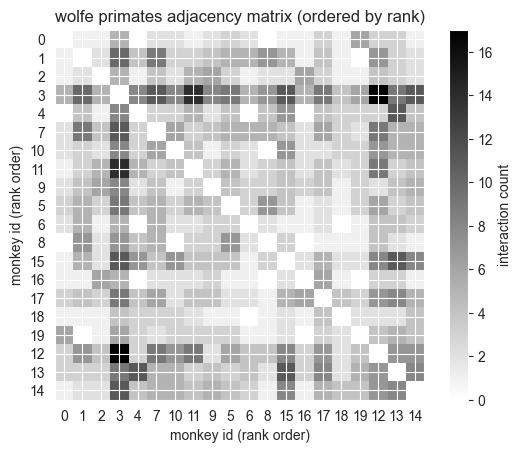

In [6]:
# visualize adjacency matrix
plt.imshow(link_m, cmap="binary", interpolation="none")
plt.title("wolfe primates adjacency matrix (ordered by rank)")
plt.xlabel("monkey id (rank order)")
plt.ylabel("monkey id (rank order)")
plt.xticks(range(len(ordered_ids)), ordered_ids)
plt.yticks(range(len(ordered_ids)), ordered_ids)
plt.colorbar(label="interaction count")
plt.show()

#### Part 1.2 edgelist (10 points)

Convert the data into a edgelist data frame with three columns: source, target and weight. 

In [7]:
# build edgelist
n = link_m.shape[0]
i, j = np.triu_indices(n, k=1)
w = link_m.values[i, j]
mask = w > 0

edgelist = pd.DataFrame({
    "source": ordered_ids[i[mask]],
    "target": ordered_ids[j[mask]],
    "weight": w[mask]
})

#### Part 1.3 Make a static network (10 points)

Use the edgelist generated from part 1.2, make a bipartite network, such that one side is for male and the other side is for female. The colors of the nodes are decided by the gender. The sizes of the nodes are decided by the age. The width of the edges are decided by the weight. 

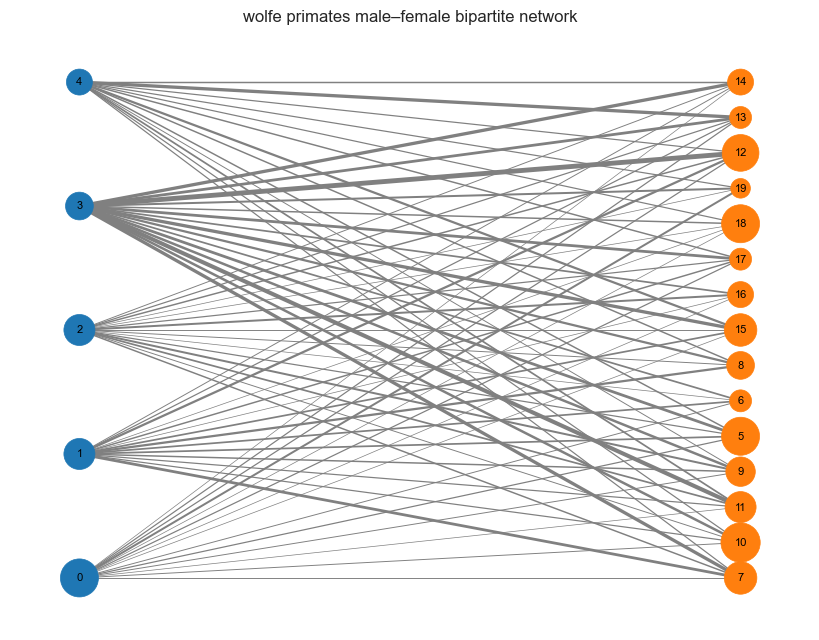

In [8]:
# make bipartite network
G = nx.Graph()
info = labels.set_index("Id")

# add nodes with attributes
for id in ordered_ids:
    G.add_node(id, sex=info.loc[id, "Sex"], age=info.loc[id, "Age"])

# add edges only between male and female
for _, row in edgelist.iterrows():
    s, t = row["source"], row["target"]
    if info.loc[s, "Sex"] == info.loc[t, "Sex"]:
        continue
    G.add_edge(s, t, weight=row["weight"])

# separate nodes by gender
males = [n for n, d in G.nodes(data=True) if d["sex"].lower().startswith("m")]
females = [n for n in G if n not in males]
pos = nx.bipartite_layout(G, males)

# node size by age
ages = np.array([d["age"] for _, d in G.nodes(data=True)])
a_min, a_max = ages.min(), ages.max()
sizes = 200 + (ages - a_min) / (a_max - a_min + 1e-6) * 600

# node color by gender
colors = ["tab:blue" if d["sex"].lower().startswith("m") else "tab:orange"
          for _, d in G.nodes(data=True)]

# edge width by weight
weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])
if len(weights) > 0:
    w_min, w_max = weights.min(), weights.max()
    widths = 0.5 + (weights - w_min) / (w_max - w_min + 1e-6) * 3
else:
    widths = 1.0

# draw graph
plt.figure(figsize=(8, 6))
nx.draw(G, pos,
        node_color=colors,
        node_size=sizes,
        width=widths,
        edge_color="gray",
        linewidths=0.5,
        font_size=8,
        with_labels=True)
plt.title("wolfe primates male–female bipartite network")
plt.show()

### Part 2 Design your own social network (20 points)

Now, let's try to visualize your own social network. Include the data file in the assignment submission. 

- Open an excel file.
- Set up an adjacency matrix for at least 10 people you know (not including yourself)
- Label the adjacency matrix based on your knowledge whether they know each other or not (You can just use 0/1 to indicate whether they know each other or not)
- Load the adjacency matrix to the Jupyter Notebook
- Convert then data to edgelist
- Plot the static network for your social network
- Now, include yourself into the network, plot the network again
- Discuss what you have seen in two networks and is there a specific layout you have chosen for your network. 

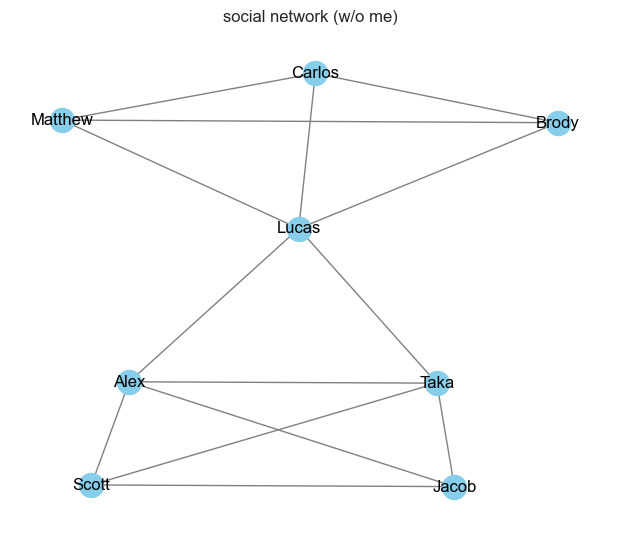

In [14]:
# load adjacency matrix without me
adj = pd.read_csv("social_netw.csv", index_col=0)

names = adj.index.tolist()
edges = []

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        if adj.iat[i, j]:
            edges.append((names[i], names[j]))

g = nx.Graph()
g.add_edges_from(edges)

pos = nx.spring_layout(g, seed=1)

plt.figure(figsize=(6, 5))
nx.draw(
    g, pos,
    with_labels=True,
    node_color="violet",
    edge_color="gray",
)
plt.title("social network (w/o me)")
plt.show()

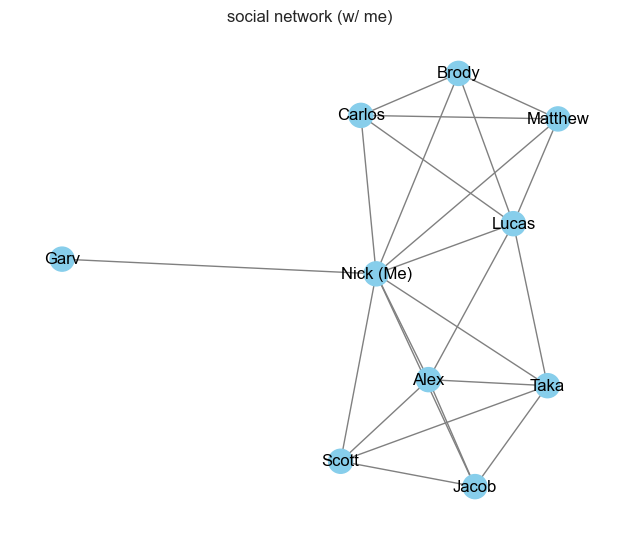

In [16]:
# load adjacency matrix with me
adj2 = pd.read_csv("social_netw_me.csv", index_col=0)

names2 = adj2.index.tolist()
edges2 = []

for i in range(len(names2)):
    for j in range(i + 1, len(names2)):
        if adj2.iat[i, j]:
            edges2.append((names2[i], names2[j]))

g2 = nx.Graph()
g2.add_edges_from(edges2)

pos2 = nx.spring_layout(g2, seed=1)

colors = ["orange" if n.lower() == "nick" else "skyblue" for n in g2.nodes()]

plt.figure(figsize=(6, 5))
nx.draw(
    g2, pos2,
    with_labels=True,
    node_color=colors,
    edge_color="gray",
)
plt.title("social network (w/ me)")
plt.show()

### Part 3 Exploratory vs. Explanatory writing

Following is an automobile data downloaded from the UCI repository. Here is the link for the data in case you cannot run the script. You can also download the csv, attached on Canvas and run it. 

https://archive.ics.uci.edu/dataset/10/automobile

In [17]:
#pip install ucimlrepo

import seaborn as sns

In [18]:
#from ucimlrepo import fetch_ucirepo

#automobile = fetch_ucirepo(id=10)
#X = automobile.data.features
#X.head()

#
# load data
df = pd.read_csv("automobile.csv")
df = df.replace("?", np.nan)

# keep only rows with usable fields
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=["body-style", "price", "horsepower"])

#### Part 3.1 Boxplot (10 points)

Following is boxplot between price and body style of the car. Please write one paragraph of exploratory interpretation and one paragraph of explanatory interpretation. 

(Note: Exploratory interpretation will be a more comprehensize analysis on every aspects of the visualization. It is more objective and focus more on reporting the statistics. Explanatory interpretation is more subjective and usually focus on only one or two aspects of the visualization. It will address more context and qualitive analysis. )

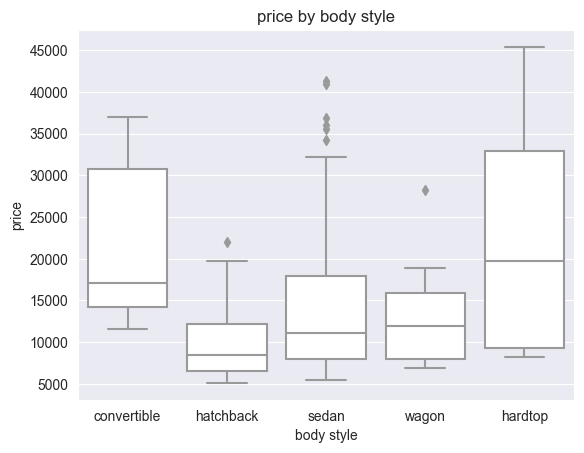

In [20]:
# boxplot - price vs body style
sns.boxplot(x=df["body-style"], y=df["price"], color="white")
plt.title("price by body style")
plt.xlabel("body style")
plt.ylabel("price")
plt.show()

**Explanation -
- The boxplot represents variation in car prices across 5 different car body styles (convertible, hatch, sedan, wagon, hardtop)
- Rarer, more unique body types like the hardtops and convertible cars have higher median prices, with higher Max values, and wider ranges.
- Less-common body types like wagon and hatchback all have tighter distributions, with lower avg price, median, max and min.

So, convertible and hardtops are the most expensive body types, while practical body types like hatchbacks have lower average price, meaning they appeal more towards budget-oriented or lower-income individuals, while convertible and hardtops are the opposite

#### Part 3.2 Scatterplot (15 points)

Following is scatter plot between price and horsepower of the car. Please write one paragraph of exploratory interpretation and one paragraph of explanatory interpretation. Also, in the third paragraph, think about at least two different ways to mofidy on the scatter plot in order to boost different stories in the explanatory interpretation. 

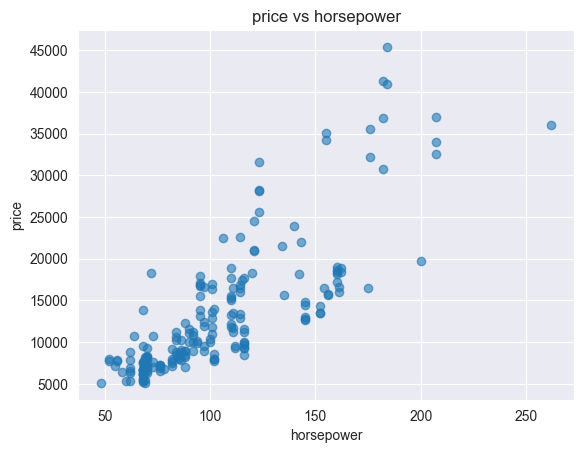

In [21]:
# scatterplot -  price vs horsepower
plt.scatter(df["horsepower"], df["price"], alpha=0.6)
plt.title("price vs horsepower")
plt.xlabel("horsepower")
plt.ylabel("price")
plt.show()

**Explanation:
- The scatterplot shows a clear, linear,positive trend that correlates horsepower directly to the price of a car.
- higher horsepower = higher price (on average)
- Spread of hp to price increases as the horsepower increases as well, particularly past ~125hp.
- Many cluseters around or below 100hp, which may mean the cars in the dataset are old, as most cars now make at least 200hp.

So, horsepower is a strong indicator of price for a car, but not all same/similar horsepower cars have bigger price differences, which can be explained by other features/factors (luxury, # of seats, # of doors, etc).

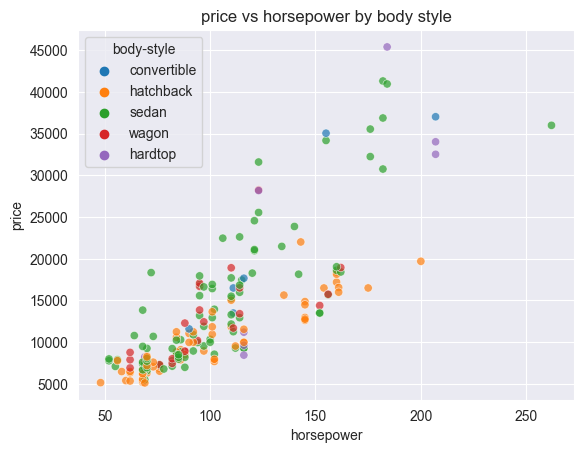

In [22]:
# colored scatter (opt)
sns.scatterplot(data=df, x="horsepower", y="price", hue="body-style", alpha=0.7)
plt.title("price vs horsepower by body style")
plt.xlabel("horsepower")
plt.ylabel("price")
plt.show()

**Explanation -
- I used color to differentiate the price vs horsepower, while charting body-style through color
- Makes it easier to visualize different body styles and how they are represented around the same curve
- It also factors in body-style factorized pricing, not just based on the hp output by the car.

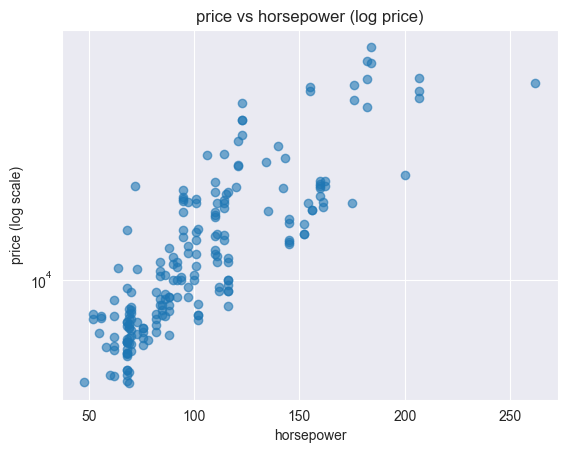

In [23]:
# log‑scaled price
plt.scatter(df["horsepower"], df["price"], alpha=0.6)
plt.yscale("log")
plt.title("price vs horsepower (log price)")
plt.xlabel("horsepower")
plt.ylabel("price (log scale)")
plt.show()

**Explanation -
- Same as previous - clusters at lower log hp, with avg price increasing in line with horsepower.
- There are still other factors un-accounted for, but the two have a correlated relationship with value/cost return
- I used log price to try to see if the outliers affected the trend of the model
- I was wrong, and the shfit in focus from extremes to average did not influence the results much

Epl


### Part 4 In-class activities for the Interview (10 points)

In-class activities about the interview (The last slides for the peer-review and interview). Type your writing paragraph about the interview result as well as 3 visualization ideas based on the result.

My Peer Review was on a project for Video Games Sales.

My peer explained that the Dataset contained Video Game Sales from VG Charts.com - a UK-based game tracking site that provided csv files on sales for video games (indie, AAA, etc). The biggest features within the dataset are video games, genre, sales in millions, and region/country. The dataset focused primarily on games from North America, Europe, and Japan as most games originate from those areas. Additional features included Publisher, Platform, and Year Released.

Their project plan was primarily focused on 3 questions -
1. What features make a video game successful?
2. Do successful video games vary by region?
3. What specific features succeed on a regional vs global basis?

Based on this, I had 3 different visualization ideas for the project -
1. Global Sales by Genre (Box Plot)
- Covering all genres in the dataset to differentiate an above-average selling genre.
2. Regional Success Heatmap
- To find how regions influence video game success, how features differ in success on a regional vs global scale
3. Platform Share by Region (Stacked Bar)
- Answers what features succeed on a regional basis, comparing Playstation, Xbox, Nintendo, and PC (Steam, Epic Games, etc).

### Part 5 Final Project Review Reflection(15 points)

Please answer this question after peer-reviewing at least 10 project groups. Notice that even your group do the peer-review as a group, you should complete this assignment individually. Sharing the answers are encouraged after the assignment submission. 

Please write a short reflection (around 1–2 paragraphs) discussing three specific things that you and your group could improve in your own project based on what you observed from others’ work.
The goal of this reflection is to encourage you to learn from your peers’ approaches — including their design choices, storytelling techniques, and analytical strategies — and to think critically about how your own project could be enhanced.

Here are some example directions your reflection might take:

- Visualization design: Try a new chart type or layout that you found effective in others’ projects.
- Interpretation and storytelling: Clarify or strengthen the narrative or explanations in your visualizations.
- Design aesthetics: Adjust color schemes, font choices, or spacing to create a more cohesive visual style.
- Structure and flow: Reorganize or reorder visualizations to improve the logical flow of your story.
- Data or analysis: Refine your dataset, include additional features, or try a different analytical perspective.
- Interactivity: Add or modify interactive elements (e.g., tooltips, filters, hover effects) to improve engagement.
- Accessibility and clarity: Improve labeling, legends, or color contrast to make your work easier to understand.
- Collaboration and workflow: Reflect on how your group could coordinate more effectively or divide tasks differently.

There were a few things I believe my group might have fallen short on, especially after reviewing 20+ peer reviews of different projects.

1. Design Aesthetics
- From the design portion, after looking at a few example projects, I feel like the general style that we went for wasn't enough.
- That being said, there were a few projects which contained no unique style or characteristics, but there were other's whose use of bold/underlining, special fonts, and text colors that made the project come together in a more interactive way.
- In one, for example, the Peer made seperate tabs for each of the visualizations, then made a conclusion tab that included all visualizations, and concise, bulleted explanations to wrap up the project nicely.
- Some other projects didn't use tabs at all, and instead were scroll-through only.
- Taking from this, a few adjustments can be made to the sizing, font, bullets, and overall design of the page, even if I still think it was above average for the other project's I saw.

2. Accessibility
- One of the biggest issues our project had was the implementation of the graphs within the html file.
- This was specifically my part, and I spent a lot of time trying to fix and decode why the graphs only showed up correctly after refreshing the page. Many other projects did not have this problem, and it is something we need to fix.
- I feel like our color contrast was good too, and we also included a tooltip below each visualization, explaining exactly how to use the graph (for plotly, altair, etc)

3. Intepretation and Storytelling
- For intepretation/storytelling of the problem and how it can be explained using the visualizations, I feel like we could've done a better job bulleting/organizing the information
- The instructions said paragraphs, so we used paragraphs, but I saw in a peer's project that they used some bullets to denote the important information.
- Pairing this with bold/underlined text for important ideas or numbers could've helped get the point across using less space and words.